# 1-Import Libraries

In [13]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# 2-Load Data

In [6]:
true_df = pd.read_csv("True - True.csv", engine='python')
fake_df = pd.read_csv("Fake - Fake.csv", engine='python')

true_df["label"] = 1   # True
fake_df["label"] = 0   # Fake

df = pd.concat([true_df, fake_df])
df = df.sample(frac=1).reset_index(drop=True)  # shuffle

In [5]:
!tail -n 20 "True - True.csv"

Germany's Schulz says he would demand U.S. withdraw nuclear arms,"BERLIN (Reuters) - The leader of Germany s Social Democrats (SPD) pledged to have U.S. nuclear weapons withdrawn from German territory if, against the odds, he defeats Angela Merkel to become chancellor next month. Addressing a campaign rally in Trier late on Tuesday, SPD leader Martin Schulz also said he, unlike Merkel, would resist demands by U.S. President Donald Trump for NATO members to increase their defense spending.  Trump wants nuclear armament. We are against this,  Schulz said, apparently trying to differentiate his party from Merkel s more hawkish Christian Democratic Union (CDU).  As chancellor, I will commit Germany to having the nuclear weapons stationed here withdrawn from our country,  he said. About 20 U.S. nuclear warheads are thought to be stationed at a military base in Buechel, in western Germany, according to unofficial estimates. The U.S. embassy in Berlin said it does not comment on nuclear weapo

#3-Preprocessing

In [8]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text) # Convert to string to handle float/non-string types
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["text"] = df["text"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#4-Tokenization + Padding

In [9]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["text"])

X = tokenizer.texts_to_sequences(df["text"])
X = pad_sequences(X, maxlen=max_len)

y = df["label"]

#5-Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#6-Build CNN Model

In [11]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# CNN Layer
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Pooling
model.add(GlobalMaxPooling1D())

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#7-Train Model

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 111s 96ms/step - accuracy: 0.9702 - loss: 0.0807 - val_accuracy: 0.9932 - val_loss: 0.0222
Epoch 2/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 106s 94ms/step - accuracy: 0.9972 - loss: 0.0103 - val_accuracy: 0.9955 - val_loss: 0.0162
Epoch 3/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 101s 90ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0.9949 - val_loss: 0.0194
Epoch 4/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 102s 91ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9929 - val_loss: 0.0255
Epoch 5/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 116s 103ms/step - accuracy: 0.9998 - loss: 0.0019 - val_accuracy: 0.9960 - val_loss: 0.0224


#8-VISUALIZATIONS

Accuracy & Loss

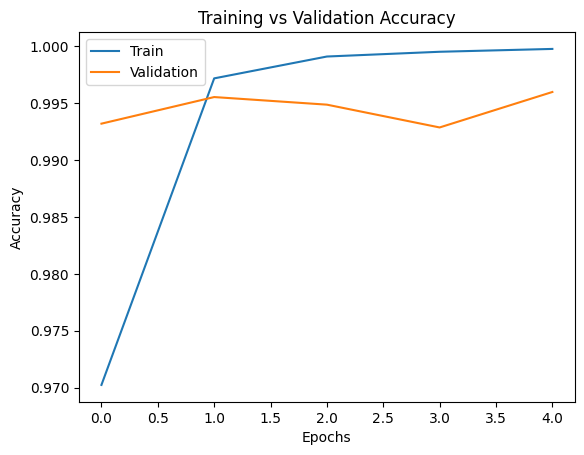

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()



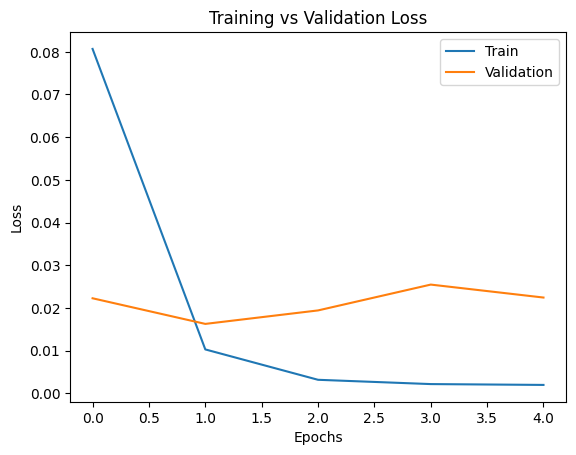

In [16]:
# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Confusion Matrix

281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


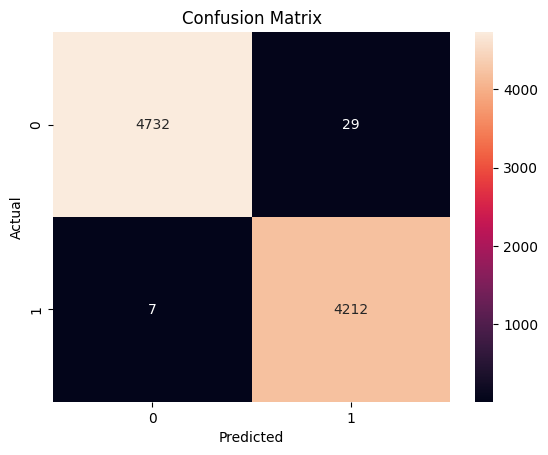

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4761
           1       0.99      1.00      1.00      4219

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



ROC Curve

281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step


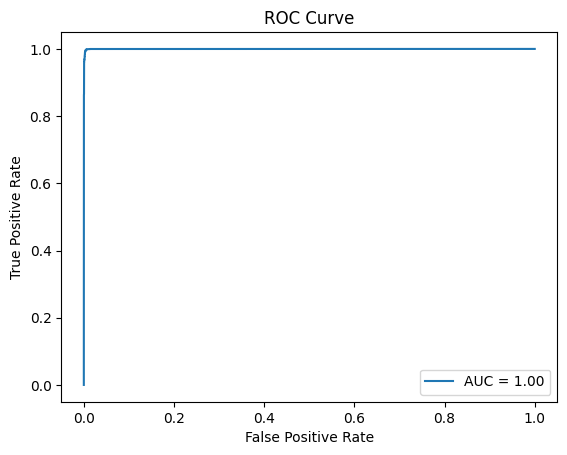

In [25]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.9960


Test New Article

In [26]:
def predict_news(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(padded)[0][0]

    if pred > 0.5:
        return "True News "
    else:
        return "Fake News "

In [27]:
article = "Government announces new economic reform plan"
print(predict_news(article))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
True News ✅
